In [1]:
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

import kwant

from scipy.sparse.linalg import eigsh
from scipy.optimize import minimize_scalar


FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)

In [2]:
# ============================================================
# BdG matrices
# ============================================================

s0 = np.eye(2, dtype=complex)

sy = np.array([
    [0, -1j],
    [1j, 0]
], dtype=complex)

sz = np.array([
    [1, 0],
    [0, -1]
], dtype=complex)

z2 = np.zeros((2, 2), dtype=complex)


# ============================================================
# Square-octagon lattice
# ============================================================

rt2 = np.sqrt(2)
a = 1 + rt2

lat_bdg = kwant.lattice.general(
    [(a, 0), (0, a)],
    [
        (0, 1 / rt2),
        (-1 / rt2, 0),
        (0, -1 / rt2),
        (1 / rt2, 0)
    ],
    norbs=4,
    name="sqoct_bdg"
)

A, B, C, D = lat_bdg.sublattices

ad_lat = kwant.lattice.general(
    [(a, 0), (0, a)https://github.com/Ravieroy/square-octagon-ysr-transport],
    [(0, 0)],
    norbs=4,
    name="adatom"
)

AD = ad_lat.sublattices[0]

In [3]:
def onsite_host(site, mu, Delta):

    h = -mu * s0
    pairing = 1j * Delta * sy

    return np.block([
        [h, pairing],
        [pairing.conj().T, -h.T]
    ])


def onsite_adatom(site, eps_d, Jd):

    h = eps_d * s0 + Jd * sz

    return np.block([
        [h, z2],
        [z2, -h.T]
    ])


def bdg_hopping(he):

    return np.block([
        [he, z2],
        [z2, -he.conj()]
    ])


def hopping_t1(site1, site2, t1):
    return bdg_hopping(-t1 * s0)


def hopping_t2(site1, site2, t2):
    return bdg_hopping(-t2 * s0)

In [4]:
def build_adatom_system(geometry, V):

    syst = kwant.Builder()

    # Host sites
    for ix in range(Nx):
        for iy in range(Ny):
            syst[A(ix, iy)] = onsite_host
            syst[B(ix, iy)] = onsite_host
            syst[C(ix, iy)] = onsite_host
            syst[D(ix, iy)] = onsite_host

    # Host hoppings
    for ix in range(Nx):
        for iy in range(Ny):

            # Square edges
            syst[A(ix, iy), B(ix, iy)] = hopping_t1
            syst[B(ix, iy), C(ix, iy)] = hopping_t1
            syst[C(ix, iy), D(ix, iy)] = hopping_t1
            syst[D(ix, iy), A(ix, iy)] = hopping_t1

            # Periodic boundary conditions
            syst[C(ix, iy), A(ix, (iy + 1) % Ny)] = hopping_t1
            syst[B(ix, iy), D((ix + 1) % Nx, iy)] = hopping_t1

            # Diagonal hopping
            syst[A(ix, iy), C(ix, iy)] = hopping_t2
            syst[B(ix, iy), D(ix, iy)] = hopping_t2

    # Adsorption geometry
    if geometry == "Top":
        cluster = [A(0, 0)]

    elif geometry == "Square":
        cluster = [
            A(0, 0), B(0, 0),
            C(0, 0), D(0, 0)
        ]

    elif geometry == "Octagon":
        cluster = [
            D(0, 0), B(1, 0),
            A(1, 0), C(1, 1),
            B(1, 1), D(0, 1),
            C(0, 1), A(0, 0)
        ]

    else:
        raise ValueError("geometry must be Top, Square, or Octagon")

    # Adatom
    ad_site = AD(0, 0)
    syst[ad_site] = onsite_adatom

    # Equal hybridization with all sites in the cluster
    Nc = len(cluster)
    hyb = bdg_hopping((V / np.sqrt(Nc)) * s0)

    for host_site in cluster:
        syst[ad_site, host_site] = hyb

    return syst.finalized(), ad_site

In [5]:
def near_zero_state(fsyst, params):

    H = fsyst.hamiltonian_submatrix(
        params=params,
        sparse=True
    )

    vals, vecs = eigsh(
        H, k=8,
        sigma=1e-8, which="LM",
        tol=1e-9, maxiter=50000
    )

    index = np.argmin(np.abs(vals))

    return vals[index].real, vecs[:, index]


def bound_energy(fsyst, params, Jd):

    p = dict(params)
    p["Jd"] = Jd

    E, _ = near_zero_state(fsyst, p)

    return abs(E)


def find_crossing(fsyst, params, Jmax=1.5):

    Jgrid = np.linspace(0.05, Jmax, 41)

    Egrid = np.array([
        bound_energy(fsyst, params, J)
        for J in Jgrid
    ])

    i = np.argmin(Egrid)

    lo = Jgrid[max(0, i - 1)]
    hi = Jgrid[min(len(Jgrid) - 1, i + 1)]

    result = minimize_scalar(
        lambda J: bound_energy(fsyst, params, J),
        bounds=(lo, hi),
        method="bounded",
        options={"xatol": 2e-5}
    )

    Jstar = result.x

    p = dict(params)
    p["Jd"] = Jstar

    E, vec = near_zero_state(fsyst, p)

    return Jstar, E, vec

In [13]:
# ============================================================
# Parameters
# ============================================================
Nx = 8
Ny = 6

Delta = 0.20
eps_d = 0.50
V = 0.80
t1 = 1.0
t2 = 1.0
mu = 0.0

geometries = ["Top", "Square", "Octagon"]

params = {
    "mu": mu,
    "Delta": Delta,
    "t1": t1,
    "t2": t2,
    "eps_d": eps_d,
    "Jd": 0.0
}

In [14]:
systems = {}

for geometry in geometries:
    systems[geometry] = build_adatom_system(
        geometry=geometry,
        V=V
    )

In [15]:
J_values = np.linspace(0.0, 1.35, 70)

E_top = np.array([
    bound_energy(systems["Top"][0], params, J)
    for J in J_values
])

E_square = np.array([
    bound_energy(systems["Square"][0], params, J)
    for J in J_values
])

E_octagon = np.array([
    bound_energy(systems["Octagon"][0], params, J)
    for J in J_values
])

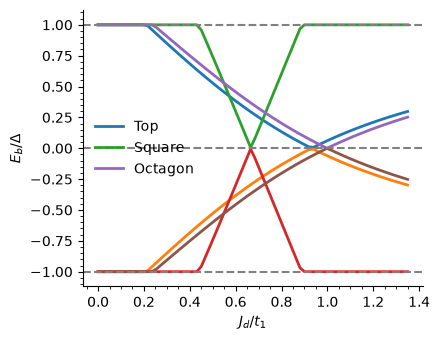

In [16]:
fig, ax = plt.subplots(figsize=(4.5, 3.5))


ax.plot(
    J_values, +E_top / Delta,
    lw=2, label="Top"
)

ax.plot(
    J_values, -E_top / Delta,
    lw=2
)


ax.plot(
    J_values, +E_square / Delta,
    lw=2, label="Square"
)

ax.plot(
    J_values, -E_square / Delta,
    lw=2
)


ax.plot(
    J_values, +E_octagon / Delta,
    lw=2, label="Octagon"
)

ax.plot(
    J_values, -E_octagon / Delta,
    lw=2
)


# Gap edges and zero energy
ax.axhline(1, color="gray", ls="--")
ax.axhline(-1, color="gray", ls="--")
ax.axhline(0, color="gray", ls="--")


ax.set_xlabel(r"$J_d/t_1$")
ax.set_ylabel(r"$E_b/\Delta$")

ax.set_ylim(-1.12, 1.12)

ax.legend(frameon=False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.minorticks_on()


plt.tight_layout()

# plt.savefig(
#     FIG_DIR / "adatom_bound_state.pdf",
#     dpi=600, bbox_inches="tight"
# )

plt.show()

In [17]:
Jc = {}
Wd = {}


for geometry in geometries:

    fsyst, ad_site = systems[geometry]

    Jstar, E, vec = find_crossing(
        fsyst, params,
        Jmax=1.5
    )

    # Weight on the adatom
    iad = fsyst.id_by_site[ad_site]
    ad_slice = slice(4 * iad, 4 * iad + 4)

    weight = np.sum(
        np.abs(vec[ad_slice])**2
    ).real

    Jc[geometry] = Jstar
    Wd[geometry] = weight

    print(
        f"{geometry:8s}  "
        f"Jc = {Jstar:.5f}   "
        f"E = {E:+.2e}   "
        f"W_d = {weight:.4f}   "
        f"W_host = {1-weight:.4f}"
    )

Top       Jc = 0.93105   E = -3.65e-07   W_d = 0.1867   W_host = 0.8133
Square    Jc = 0.66643   E = -2.84e-06   W_d = 0.9021   W_host = 0.0979
Octagon   Jc = 0.99902   E = +5.11e-07   W_d = 0.1794   W_host = 0.8206


In [18]:
Wd_values = np.array([
    Wd["Top"],
    Wd["Square"],
    Wd["Octagon"]
])

Whost_values = 1.0 - Wd_values

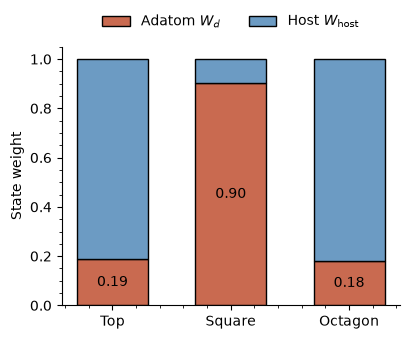

In [19]:
x = np.arange(3)


fig, ax = plt.subplots(figsize=(4.2, 3.5))


# Adatom weight
ax.bar(
    x, Wd_values,
    width=0.60,
    color="#C96A50",
    edgecolor="black",
    label=r"Adatom $W_d$"
)


# Host weight
ax.bar(
    x, Whost_values,
    width=0.60,
    bottom=Wd_values,
    color="#6C9BC3",
    edgecolor="black",
    label=r"Host $W_{\rm host}$"
)


ax.set_xticks(x)
ax.set_xticklabels(geometries)

ax.set_ylabel("State weight")
ax.set_ylim(0, 1.05)


# Adatom weights inside the bars
for i, w in enumerate(Wd_values):
    ax.text(
        i, w / 2,
        f"{w:.2f}",
        ha="center", va="center"
    )


ax.legend(
    loc="lower center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=2,
    frameon=False
)


ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.minorticks_on()


plt.tight_layout()

# plt.savefig(
#     FIG_DIR / "adatom_state_character.pdf",
#     dpi=600, bbox_inches="tight"
# )

plt.show()